# 1.4 Speech Dataset Exploratory Data Analysis

Dataset: TORGO Audio Dataset

Purpose:
- Validate downloaded audio files
- Build an audio manifest
- Inspect class balance
- Inspect duration distribution
- Inspect sample-rate distribution
- Identify preprocessing issues

Project relevance:
This dataset supports the Speech Analysis Module. It is used as a public proxy dataset for dysarthric/slurred speech, which relates to the FAST speech-warning component in stroke triage.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

from rural_stroke_assist.config import SPEECH_DATA_DIR, INTERIM_DATA_DIR, FIGURES_DIR
from rural_stroke_assist.preprocessing.audio import (
    list_audio_files,
    is_audio_readable,
    get_audio_metadata,
    infer_speech_label_from_path,
    infer_torgo_group_from_path,
    infer_torgo_speaker_from_path,
)
from rural_stroke_assist.plots import save_bar_plot, save_histogram

In [2]:
print("Speech dataset directory:", SPEECH_DATA_DIR)
print("Exists:", SPEECH_DATA_DIR.exists())

Speech dataset directory: C:\Users\Asus\Downloads\Uni_work\Grad-Project\rural-stroke-assist\data\raw\torgo_audio
Exists: True


In [3]:
for path in list(SPEECH_DATA_DIR.rglob("*"))[:100]:
    print(path.relative_to(SPEECH_DATA_DIR))

F_Con
F_Dys
M_Con
M_Dys
F_Con\wav_arrayMic_FC01S01
F_Con\wav_arrayMic_FC02S02
F_Con\wav_arrayMic_FC02S03
F_Con\wav_arrayMic_FC03S01
F_Con\wav_arrayMic_FC03S02
F_Con\wav_arrayMic_FC03S03
F_Con\wav_headMic_FC01S01
F_Con\wav_headMic_FC02S03
F_Con\wav_headMic_FC03S01
F_Con\wav_headMic_FC03S02
F_Con\wav_headMic_FC03S03
F_Dys\wav_arrayMic_F01
F_Dys\wav_arrayMic_F03S01
F_Dys\wav_arrayMic_F03S02
F_Dys\wav_arrayMic_F03S03
F_Dys\wav_arrayMic_F04S01
F_Dys\wav_arrayMic_F04S02
F_Dys\wav_headMic_F01
F_Dys\wav_headMic_F03S01
F_Dys\wav_headMic_F03S02
F_Dys\wav_headMic_F03S03
F_Dys\wav_headMic_F04S02
M_Con\wav_arrayMic_MC01S01
M_Con\wav_arrayMic_MC01S02
M_Con\wav_arrayMic_MC01S03
M_Con\wav_arrayMic_MC02S01
M_Con\wav_arrayMic_MC02S02
M_Con\wav_arrayMic_MC03S01
M_Con\wav_arrayMic_MC03S02
M_Con\wav_arrayMic_MC04S01
M_Con\wav_arrayMic_MC04S02
M_Con\wav_headMic_MC01S01
M_Con\wav_headMic_MC01S02
M_Con\wav_headMic_MC01S03
M_Con\wav_headMic_MC02S01
M_Con\wav_headMic_MC02S02
M_Con\wav_headMic_MC03S01
M_Con\wav_

In [4]:
audio_paths = list_audio_files(SPEECH_DATA_DIR)

print(f"Total audio files found: {len(audio_paths)}")
audio_paths[:5]

Total audio files found: 17633


[WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/data/raw/torgo_audio/M_Dys/wav_arrayMic_M01S01/wav_arrayMic_M01S01_0001.wav'),
 WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/data/raw/torgo_audio/M_Dys/wav_arrayMic_M01S01/wav_arrayMic_M01S01_0002.wav'),
 WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/data/raw/torgo_audio/M_Dys/wav_arrayMic_M01S01/wav_arrayMic_M01S01_0003.wav'),
 WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/data/raw/torgo_audio/M_Dys/wav_arrayMic_M01S01/wav_arrayMic_M01S01_0004.wav'),
 WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/data/raw/torgo_audio/M_Dys/wav_arrayMic_M01S01/wav_arrayMic_M01S01_0005.wav')]

In [5]:
records = []

for path in tqdm(audio_paths):
    readable = is_audio_readable(path)

    if readable:
        metadata = get_audio_metadata(path)
    else:
        metadata = {
            "duration_seconds": None,
            "sample_rate": None,
            "num_samples": None,
        }

    records.append(
        {
            "path": str(path),
            "file_name": path.name,
            "extension": path.suffix.lower(),
            "label": infer_speech_label_from_path(path),
            "torgo_group": infer_torgo_group_from_path(path),
            "speaker_id": infer_torgo_speaker_from_path(path),
            "readable": readable,
            **metadata,
        }
    )

speech_df = pd.DataFrame(records)
speech_df.head()

 68%|██████▊   | 12058/17633 [01:55<00:33, 168.39it/s]c:\Users\Asus\Downloads\Uni_work\Grad-Project\rural-stroke-assist\rural_stroke_assist\preprocessing\audio.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  _signal, _sample_rate = librosa.load(audio_path, sr=None, mono=True, duration=1.0)
c:\Users\Asus\Downloads\Uni_work\Grad-Project\.venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|██████████| 17633/17633 [02:32<00:00, 115.89it/s]


,path,file_name,extension,label,torgo_group,speaker_id,readable,duration_seconds,sample_rate,num_samples
0,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,wav_arrayMic_M01S01_0001.wav,.wav,dysarthric,M_Dys,wav_arrayMic_M01S01,True,9.30,16000.0,148800.0
1,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,wav_arrayMic_M01S01_0002.wav,.wav,dysarthric,M_Dys,wav_arrayMic_M01S01,True,7.80,16000.0,124800.0
2,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,wav_arrayMic_M01S01_0003.wav,.wav,dysarthric,M_Dys,wav_arrayMic_M01S01,True,8.10,16000.0,129600.0
3,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,wav_arrayMic_M01S01_0004.wav,.wav,dysarthric,M_Dys,wav_arrayMic_M01S01,True,6.15,16000.0,98400.0
4,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,wav_arrayMic_M01S01_0005.wav,.wav,dysarthric,M_Dys,wav_arrayMic_M01S01,True,12.30,16000.0,196800.0


In [6]:
speech_df.shape

(17633, 10)

In [7]:
speech_df["readable"].value_counts()

readable
True     17631
False        2
Name: count, dtype: int64

In [8]:
speech_df[speech_df["readable"] == False]

,path,file_name,extension,label,torgo_group,speaker_id,readable,duration_seconds,sample_rate,num_samples
12061,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,wav_headMic_F01_0067.wav,.wav,dysarthric,F_Dys,wav_headMic_F01,False,NaN,NaN,NaN
12062,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,wav_headMic_F01_0068.wav,.wav,dysarthric,F_Dys,wav_headMic_F01,False,NaN,NaN,NaN


In [9]:
speech_df["torgo_group"].value_counts()

torgo_group
M_Con    6778
F_Con    4677
M_Dys    3787
F_Dys    2391
Name: count, dtype: int64

In [10]:
speech_df["speaker_id"].value_counts().sort_index()

speaker_id
wav_arrayMic_F01         134
wav_arrayMic_F03S01      204
wav_arrayMic_F03S02      435
wav_arrayMic_F03S03      209
wav_arrayMic_F04S01      199
wav_arrayMic_F04S02      249
wav_arrayMic_FC01S01     256
wav_arrayMic_FC02S02     269
wav_arrayMic_FC02S03     992
wav_arrayMic_FC03S01     400
wav_arrayMic_FC03S02     386
wav_arrayMic_FC03S03     208
wav_arrayMic_M01S01      100
wav_arrayMic_M01S02      286
wav_arrayMic_M02S01      240
wav_arrayMic_M02S02      160
wav_arrayMic_M03S02      416
wav_arrayMic_M04S01      126
wav_arrayMic_M04S02      294
wav_arrayMic_M05S01      128
wav_arrayMic_MC01S01     329
wav_arrayMic_MC01S02     360
wav_arrayMic_MC01S03     419
wav_arrayMic_MC02S01     388
wav_arrayMic_MC02S02     307
wav_arrayMic_MC03S01     600
wav_arrayMic_MC03S02     300
wav_arrayMic_MC04S01     648
wav_arrayMic_MC04S02     373
wav_headMic_F01          134
wav_headMic_F03S01       204
wav_headMic_F03S02       159
wav_headMic_F03S03       214
wav_headMic_F04S02       250
wav

In [11]:
speech_df.groupby(["torgo_group", "label"]).size()

torgo_group  label     
F_Con        control       4677
F_Dys        dysarthric    2391
M_Con        control       6778
M_Dys        dysarthric    3787
dtype: int64

In [13]:
speech_class_counts = speech_df["label"].value_counts()
speech_class_percentages = speech_df["label"].value_counts(normalize=True) * 100

speech_class_balance = pd.DataFrame(
    {
        "count": speech_class_counts,
        "percentage": speech_class_percentages.round(2),
    }
)

speech_class_balance

,count,percentage
label,,
control,11455,64.96
dysarthric,6178,35.04


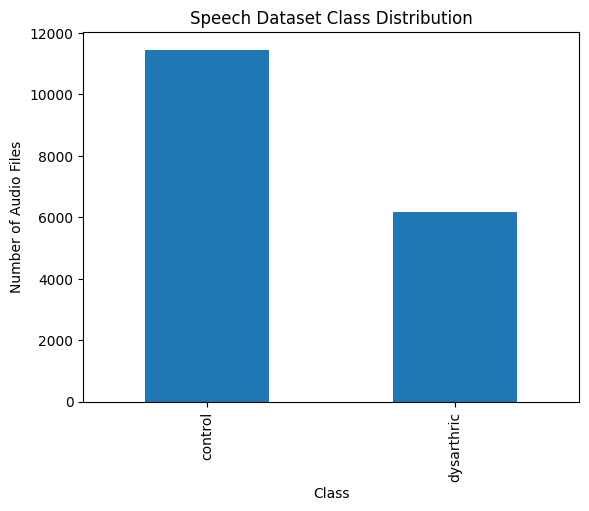

In [14]:
speech_class_counts.plot(kind="bar", title="Speech Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Audio Files")
plt.show()

In [15]:
save_bar_plot(
    series=speech_class_counts,
    title="Speech Dataset Class Distribution",
    xlabel="Class",
    ylabel="Number of Audio Files",
    output_path=FIGURES_DIR / "speech_class_distribution.png",
)

In [16]:
speech_df["duration_seconds"].describe()

count    17631.000000
mean         3.098769
std          2.935751
min          0.000000
25%          1.825000
50%          2.550000
75%          3.490000
max        193.829000
Name: duration_seconds, dtype: float64

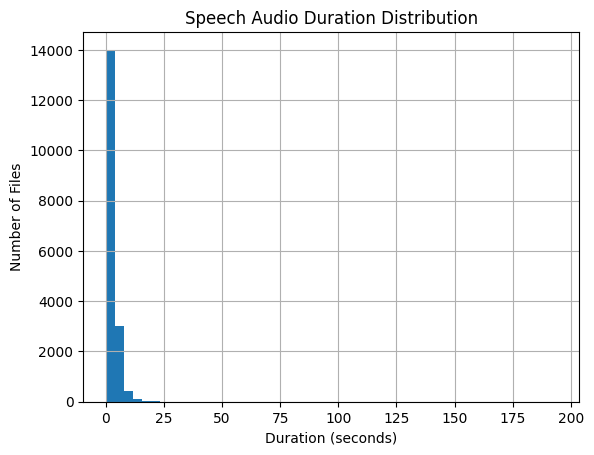

In [17]:
speech_df["duration_seconds"].dropna().hist(bins=50)
plt.title("Speech Audio Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Files")
plt.show()

In [17]:
save_histogram(
    values=speech_df["duration_seconds"].dropna(),
    title="Speech Audio Duration Distribution",
    xlabel="Duration (seconds)",
    ylabel="Number of Files",
    output_path=FIGURES_DIR / "speech_duration_distribution.png",
    bins=50,
)

In [18]:
sample_rate_counts = speech_df["sample_rate"].value_counts()
sample_rate_counts

sample_rate
16000.0    17631
Name: count, dtype: int64

In [19]:
short_audio = speech_df[speech_df["duration_seconds"] < 1.0]
long_audio = speech_df[speech_df["duration_seconds"] > 10.0]

print("Short audio files:", len(short_audio))
print("Long audio files:", len(long_audio))

short_audio.head()

Short audio files: 206
Long audio files: 301


,path,file_name,extension,label,torgo_group,speaker_id,readable,duration_seconds,sample_rate,num_samples
538,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,wav_arrayMic_M02S01_0153.wav,.wav,dysarthric,M_Dys,wav_arrayMic_M02S01,True,0.150,16000.0,2400.0
548,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,wav_arrayMic_M02S01_0163.wav,.wav,dysarthric,M_Dys,wav_arrayMic_M02S01,True,0.900,16000.0,14400.0
615,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,wav_arrayMic_M02S01_0230.wav,.wav,dysarthric,M_Dys,wav_arrayMic_M02S01,True,0.900,16000.0,14400.0
1312,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,wav_arrayMic_M04S01_0112.wav,.wav,dysarthric,M_Dys,wav_arrayMic_M04S01,True,0.604,16000.0,9660.0
1628,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,wav_arrayMic_M05S01_0007.wav,.wav,dysarthric,M_Dys,wav_arrayMic_M05S01,True,0.975,16000.0,15604.0


In [20]:
INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)

speech_df.to_csv(INTERIM_DATA_DIR / "speech_audio_manifest.csv", index=False)
speech_class_balance.to_csv(INTERIM_DATA_DIR / "speech_class_balance.csv")

print("Saved speech manifest and class balance.")

Saved speech manifest and class balance.


## Speech Dataset Preprocessing Issues

Observed preprocessing issues:

1. Dataset mismatch  
   TORGO contains dysarthric and non-dysarthric speech, but it is not stroke-specific. It is used as a proxy for speech abnormality/slurring.

2. Possible class imbalance  
   The dysarthric and control classes may not be evenly represented.

3. Speaker leakage risk  
   Train/validation/test splitting must be done by speaker, not randomly by audio file, to avoid the same speaker appearing in both training and testing.

4. Audio duration variation  
   Audio files may have different durations, requiring padding, trimming, or fixed-length feature extraction.

5. Sample-rate variation  
   Audio files may need resampling to a consistent sample rate.

6. Recording-condition variation  
   Different microphones or recording setups may affect model performance.

7. Task mismatch  
   TORGO speech tasks may not exactly match the phrase repetition task planned for the RuralStroke-Assist capture flow.